In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error , mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")


In [2]:
from google.colab import files
import io

#Upload the file
uploaded = files.upload()


for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  df = pd.read_csv(io.BytesIO(uploaded[fn]))

ModuleNotFoundError: No module named 'google.colab'

In [2]:
df = pd.read_csv("C:\\Users\\Vikash\\Desktop\\bmw_price_prediction_model\\BMW_resale_price_prediction_tool\\data\\bmw.csv")

In [3]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


# EDA

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
model,10781,24,3 Series,2443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,10781.0,NaN,NaN,NaN,2017.078935,2.349038,1996.0,2016.0,2017.0,2019.0,2020.0
price,10781.0,NaN,NaN,NaN,22733.408867,11415.528189,1200.0,14950.0,20462.0,27940.0,123456.0
transmission,10781,3,Semi-Auto,4666,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,10781.0,NaN,NaN,NaN,25496.98655,25143.192559,1.0,5529.0,18347.0,38206.0,214000.0
fuelType,10781,5,Diesel,7027,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tax,10781.0,NaN,NaN,NaN,131.702068,61.510755,0.0,135.0,145.0,145.0,580.0
mpg,10781.0,NaN,NaN,NaN,56.399035,31.336958,5.5,45.6,53.3,62.8,470.8
engineSize,10781.0,NaN,NaN,NaN,2.167767,0.552054,0.0,2.0,2.0,2.0,6.6


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  object 
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  object 
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  object 
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 758.2+ KB


In [6]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [7]:
df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
5,5 Series,2016,14900,Automatic,35309,Diesel,125,60.1,2.0
6,5 Series,2017,16000,Automatic,38538,Diesel,125,60.1,2.0
7,2 Series,2018,16250,Manual,10401,Petrol,145,52.3,1.5
8,4 Series,2017,14250,Manual,42668,Diesel,30,62.8,2.0
9,5 Series,2016,14250,Automatic,36099,Diesel,20,68.9,2.0


#Target variable is "price"

# univariate analysis numerical

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.to_list()
print(num_cols)

['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']


In [9]:
df[['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']]

,year,price,mileage,tax,mpg,engineSize
0,2014,11200,67068,125,57.6,2.0
1,2018,27000,14827,145,42.8,2.0
2,2016,16000,62794,160,51.4,3.0
3,2017,12750,26676,145,72.4,1.5
4,2014,14500,39554,160,50.4,3.0
...,...,...,...,...,...,...
10776,2016,19000,40818,150,54.3,2.0
10777,2016,14600,42947,125,60.1,2.0
10778,2017,13100,25468,200,42.8,2.0
10779,2014,9930,45000,30,64.2,2.0


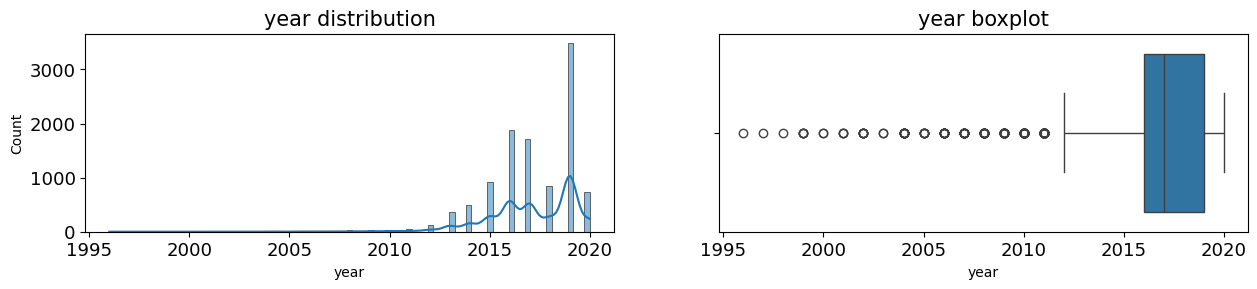

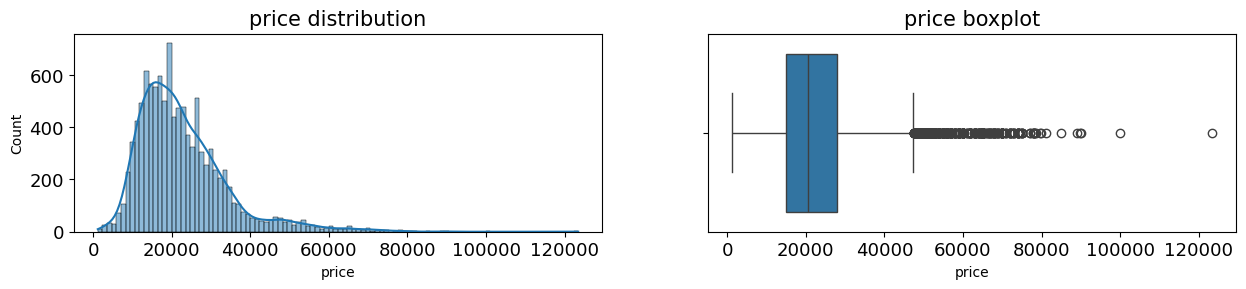

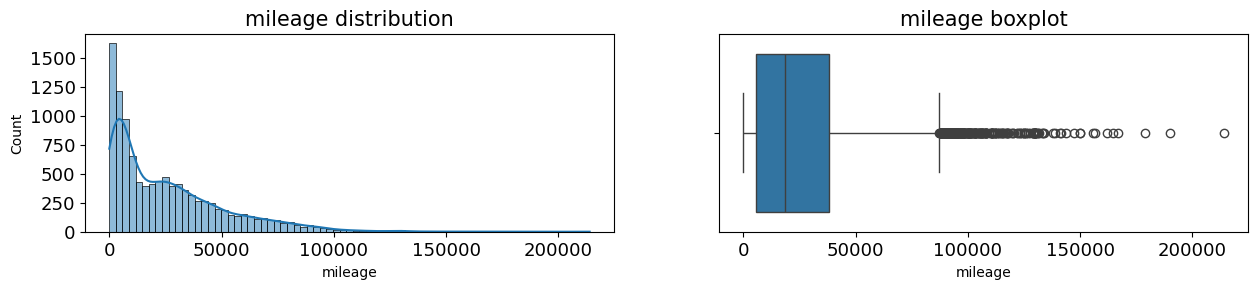

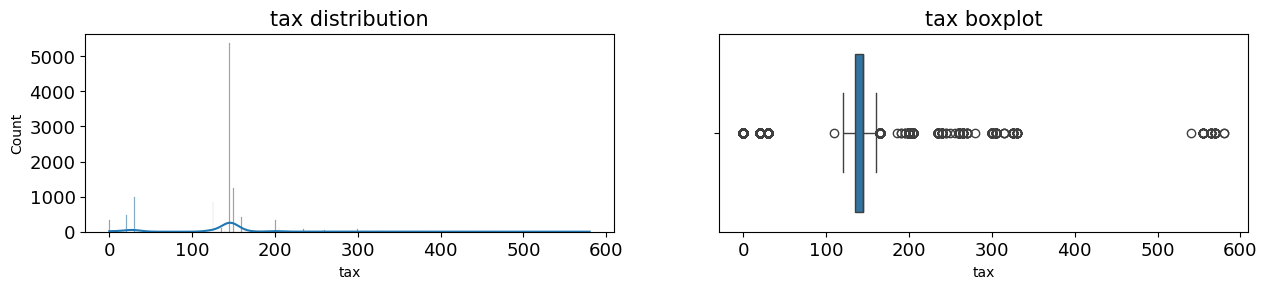

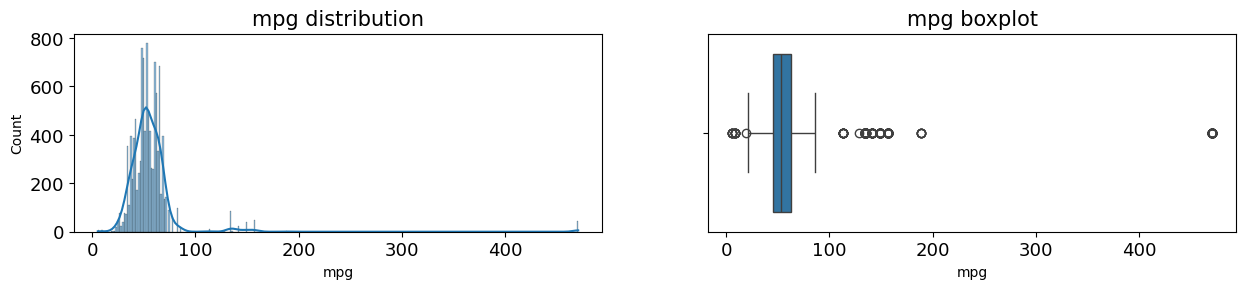

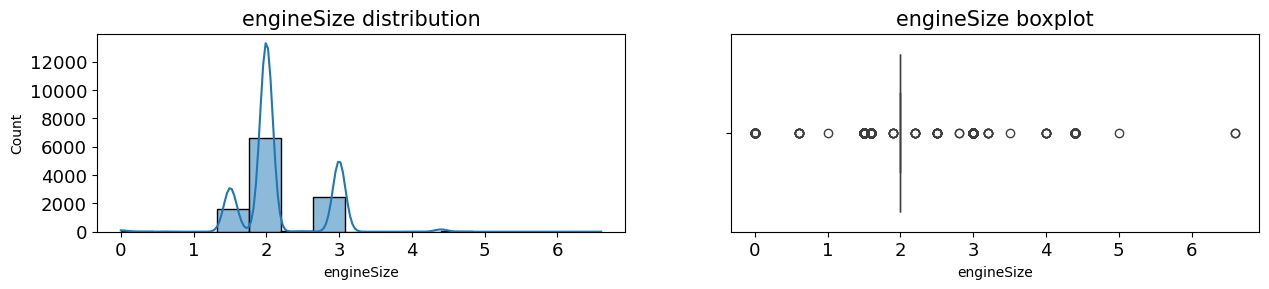

<Figure size 640x480 with 0 Axes>

In [11]:
for col in num_cols:
    plt.figure(figsize=(15,18))
    plt.subplot(6,2,1)
    sns.histplot(x = df[col],kde=True)
    plt.title(f"{col} distribution",fontsize=15)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)

    plt.subplot(6,2,2)
    sns.boxplot(data=df,x = col)
    plt.title(f"{col} boxplot",fontsize=15)
    plt.xticks(fontsize=13)

    plt.yticks(fontsize=13)
    plt.show()


In [13]:
costly_car = df[df["price"] == df["price"].max()]
high_mileage = df[df["mileage"] == df["mileage"].max()]
large_enginesize = df[df["engineSize"] == df["engineSize"].max()]
print(costly_car)
print(high_mileage)
print(large_enginesize)


          model  year   price transmission  mileage fuelType  tax   mpg  \
3638   2 Series  2015  123456    Semi-Auto    33419   Diesel   20  68.9   

      engineSize  
3638         2.0  
     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
9419    X5  2012   7250    Automatic   214000   Diesel  300  37.7         3.0
          model  year  price transmission  mileage fuelType  tax   mpg  \
9585   7 Series  2017  52950    Automatic    22000   Petrol  150  22.1   
9799   7 Series  2017  57000    Automatic    11297   Petrol  145  22.1   

      engineSize  
9585         6.6  
9799         6.6  


model 2 Series has the highest price car in the data </br>
model X5 has the highest mileage </br>
model 7 Series has the largest engine Size

In [14]:
df[df["model"].str.strip() == "2 Series"]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
7,2 Series,2018,16250,Manual,10401,Petrol,145,52.3,1.5
13,2 Series,2015,10500,Manual,31469,Diesel,20,68.9,2.0
35,2 Series,2017,13000,Automatic,61818,Other,0,141.2,1.5
72,2 Series,2017,10900,Manual,62021,Diesel,145,65.7,2.0
79,2 Series,2017,12750,Manual,33752,Petrol,125,52.3,1.5
...,...,...,...,...,...,...,...,...,...
10712,2 Series,2019,19999,Manual,313,Petrol,150,39.8,1.5
10733,2 Series,2014,10990,Manual,57000,Diesel,125,58.9,2.0
10745,2 Series,2016,14950,Automatic,49756,Diesel,30,62.8,2.0
10750,2 Series,2014,15995,Automatic,58000,Petrol,265,37.2,3.0


NOt all *2 Series* car has the same price only one car which has the highest  price , similarly </br>
*X5 model* and *model 7* both are the only car which has the highest mileage and large_enginesize repectively.

In [15]:
df.shape

(10781, 9)

# univariate analysis catigorical

In [16]:
cat_cols = df.select_dtypes(include=["category","object"]).columns.to_list()
cat_cols

['model', 'transmission', 'fuelType']

<Axes: xlabel='model'>

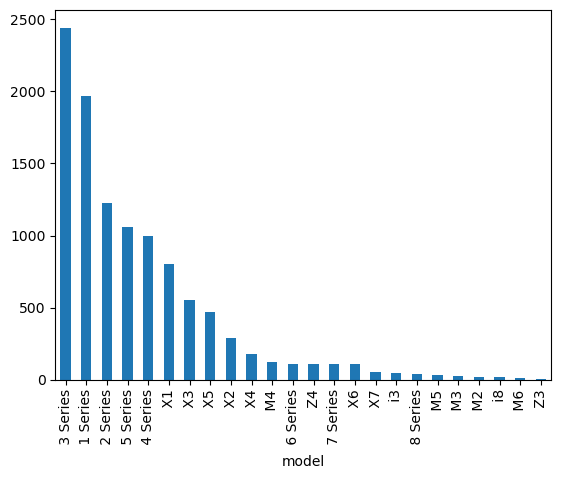

In [17]:
df["model"].value_counts().plot(kind="bar")


<Axes: ylabel='count'>

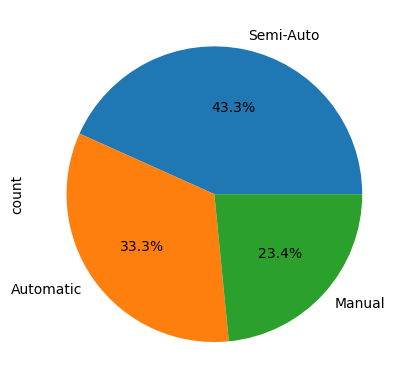

In [18]:
colors = ["blue","orange","red"]
df["transmission"].value_counts().plot.pie( autopct="%1.1f%%",color=colors)


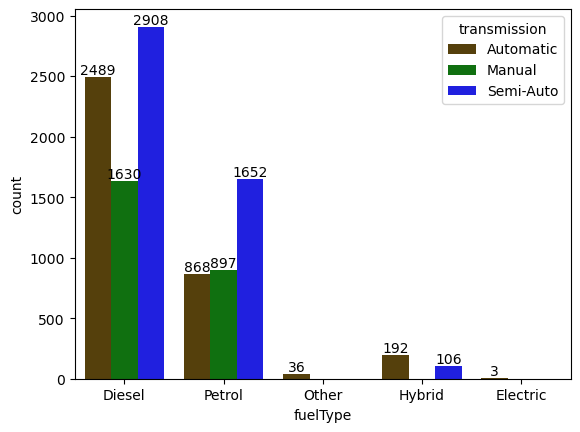

In [19]:
ax = sns.countplot(x = df["fuelType"],hue = df["transmission"],palette={"Manual": "green","Semi-Auto":"blue","Automatic": "#614500"}
)
for label in ax.containers:
    ax.bar_label(label)


# Bivarite analysis numerical-numerical

In [20]:
print(num_cols)
print(cat_cols)

['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']
['model', 'transmission', 'fuelType']


<Axes: xlabel='tax', ylabel='price'>

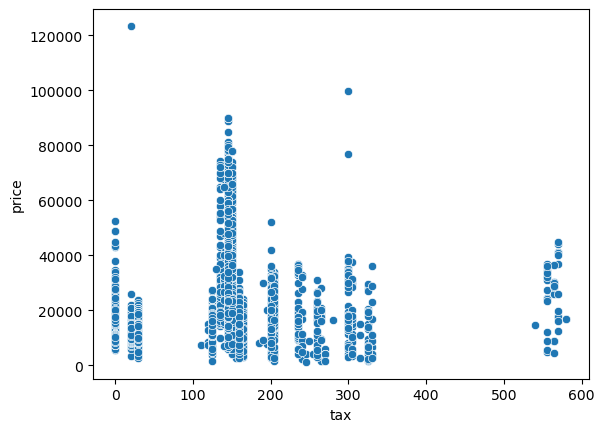

In [21]:
sns.scatterplot(data = df,x= "tax",y = "price")


<Axes: xlabel='mileage', ylabel='price'>

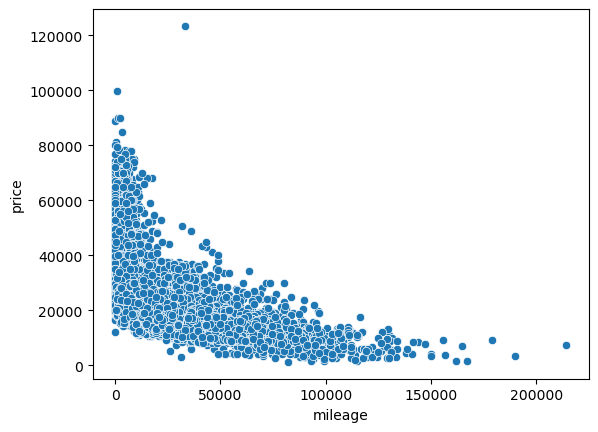

In [22]:
sns.scatterplot(data = df,x= "mileage",y = "price")


Low mileage cars has higher price and higher demand

<Axes: xlabel='mpg', ylabel='price'>

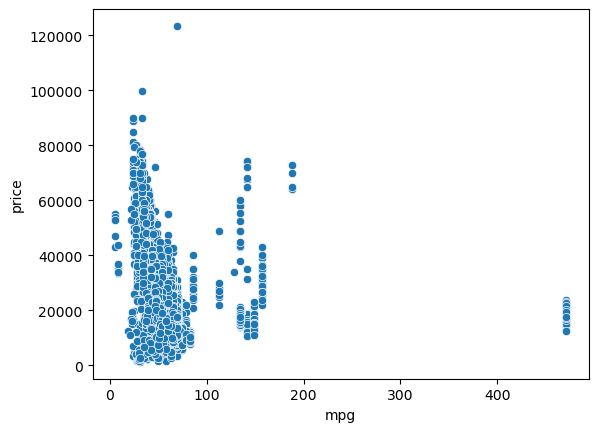

In [23]:
sns.scatterplot(data = df,x= "mpg",y = "price")


Most cars have mpg between 0-100

some cars has 100-200

few cars +400

<Axes: xlabel='engineSize', ylabel='price'>

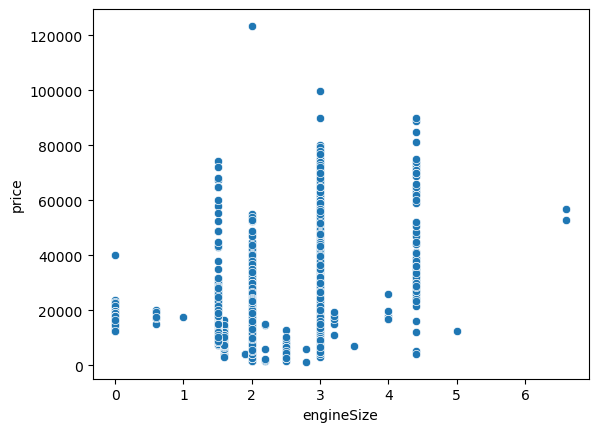

In [24]:
sns.scatterplot(data = df,x= 'engineSize',y = "price")


<Axes: xlabel='year', ylabel='price'>

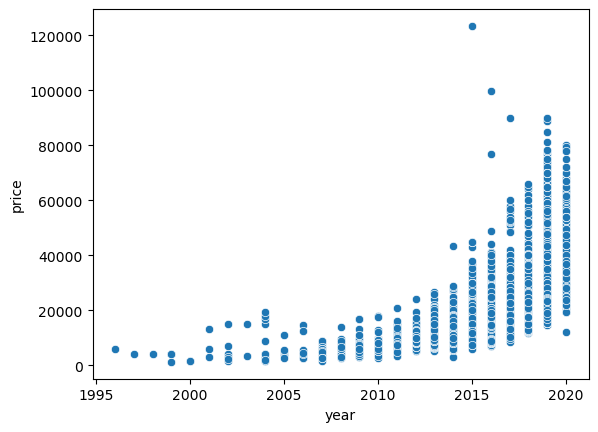

In [25]:
sns.scatterplot(x = df["year"],y = df["price"])

Increase in year cause in increase in price

Axes(0.125,0.11;0.775x0.77)


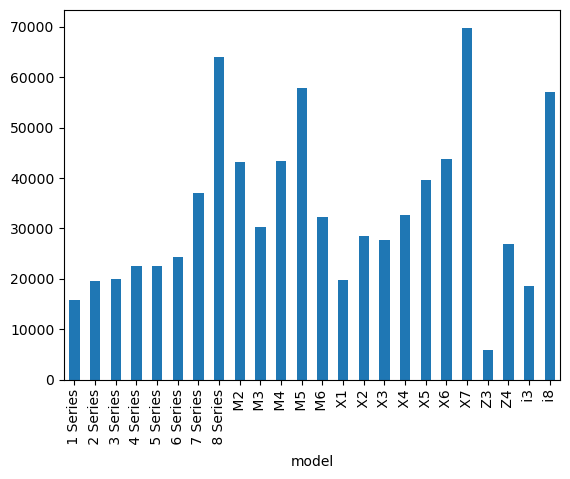

In [26]:
x  = df.groupby(df["model"])["price"].mean().plot(kind= "bar")
print(x)

Most expensive is x7 with the average of 7000

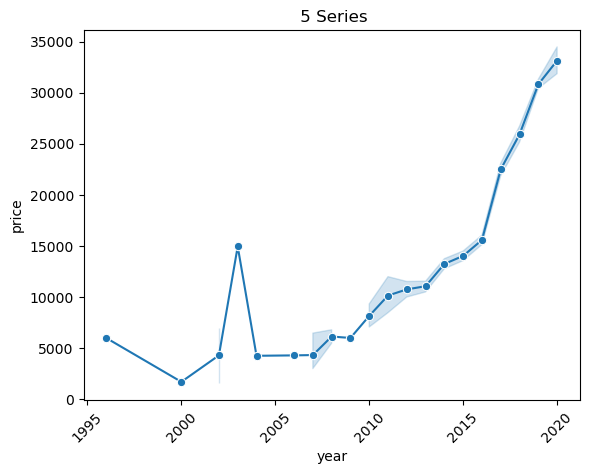

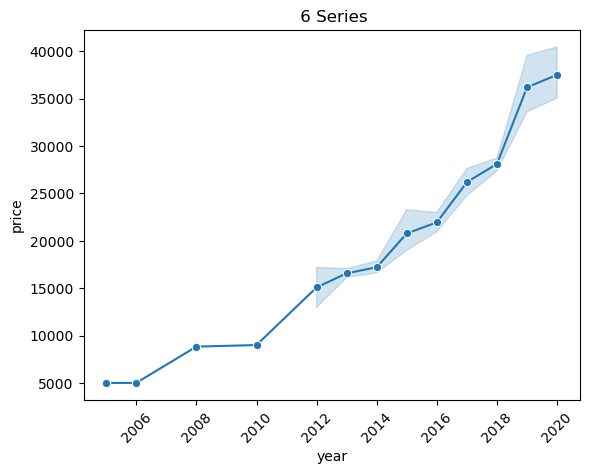

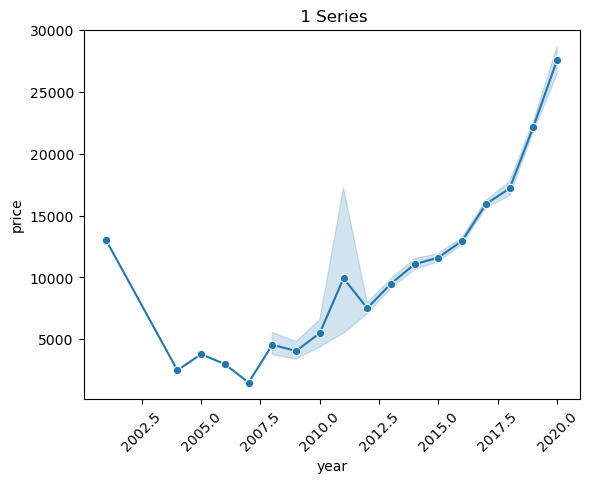

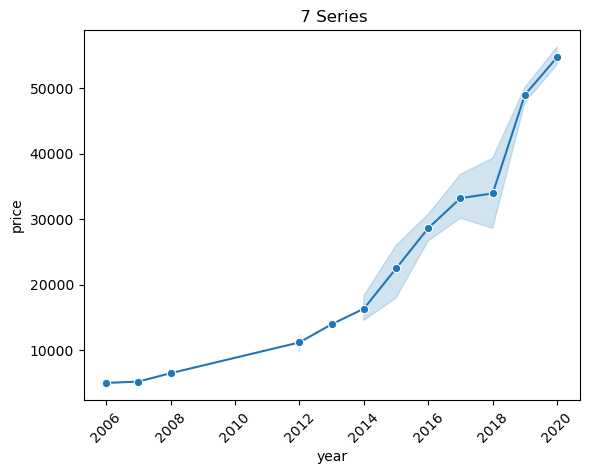

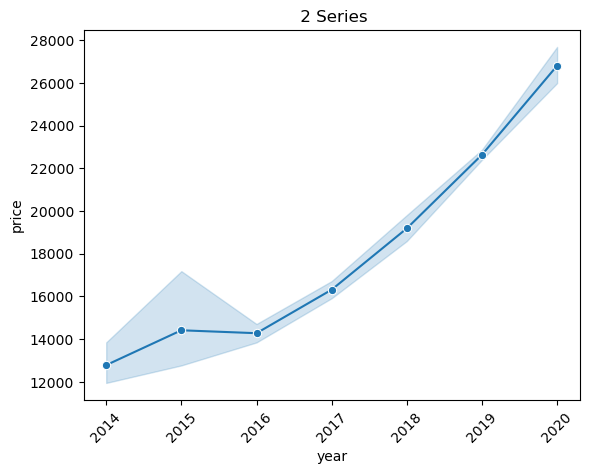

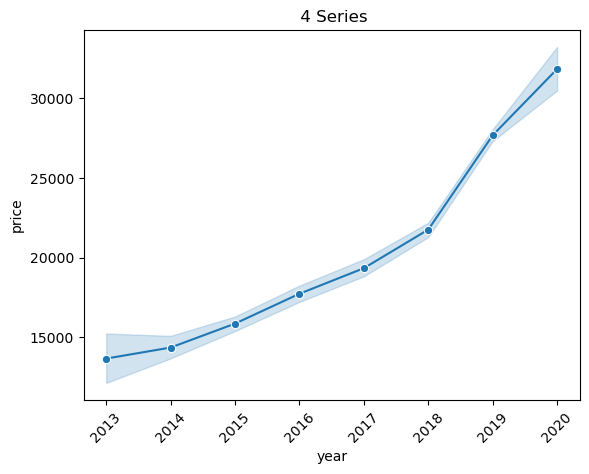

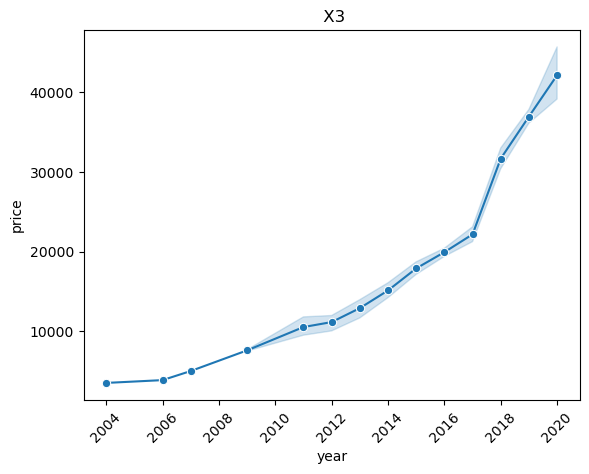

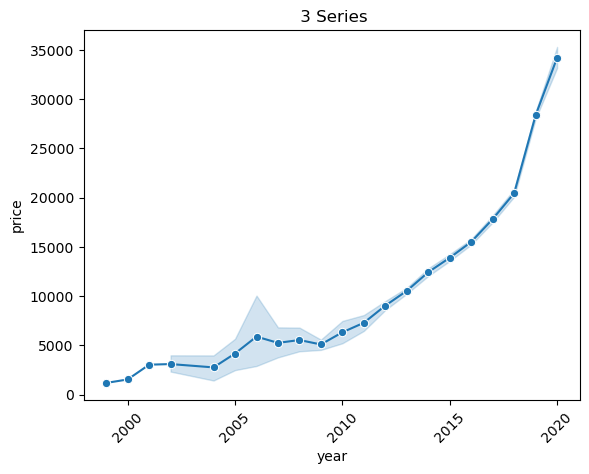

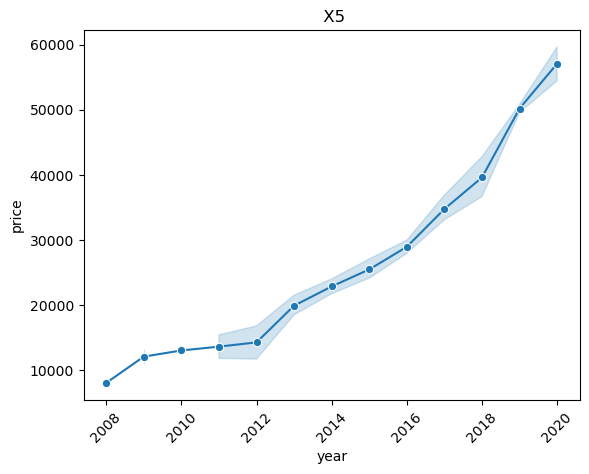

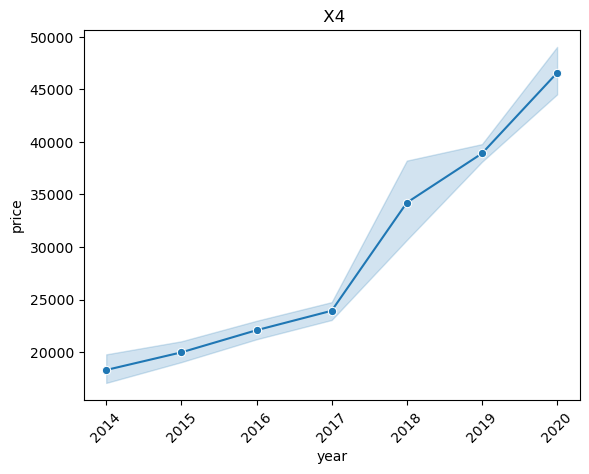

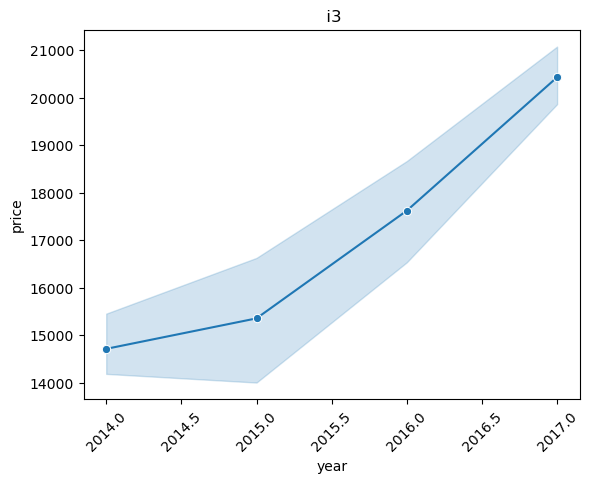

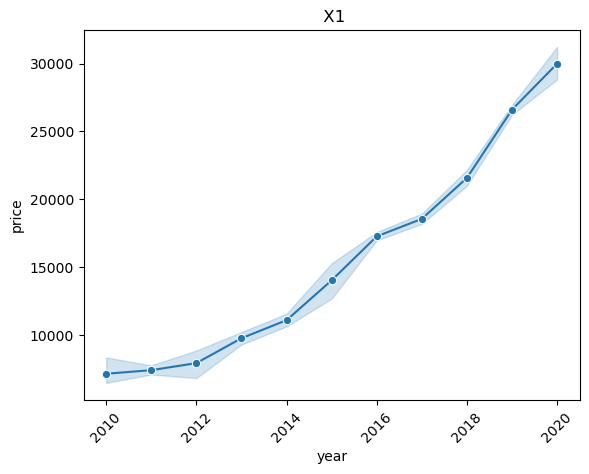

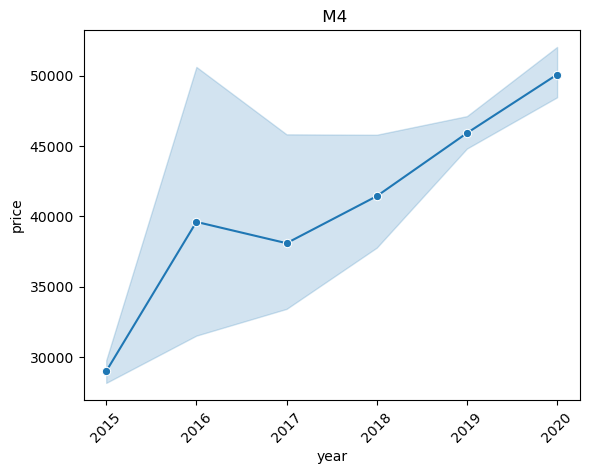

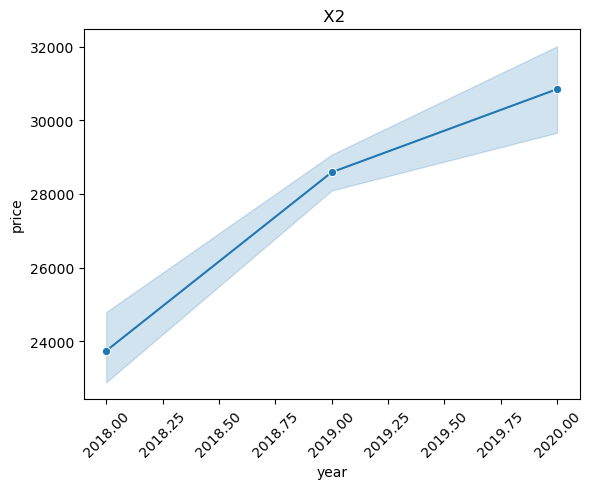

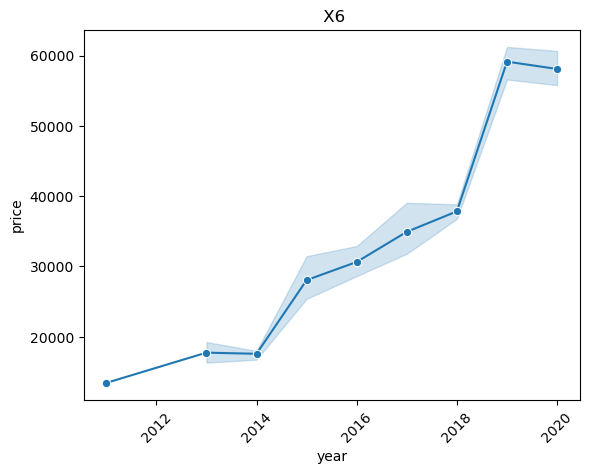

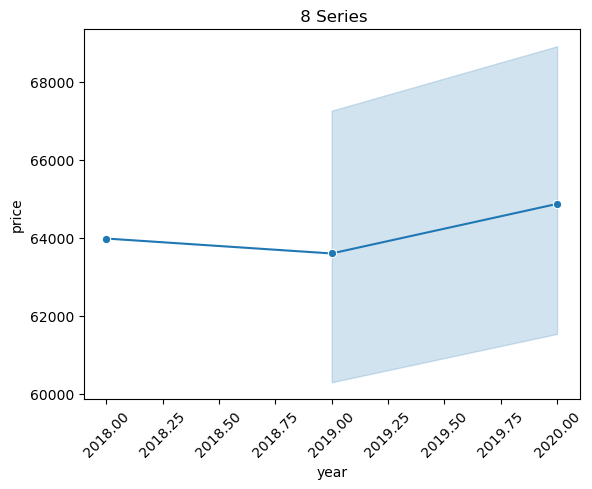

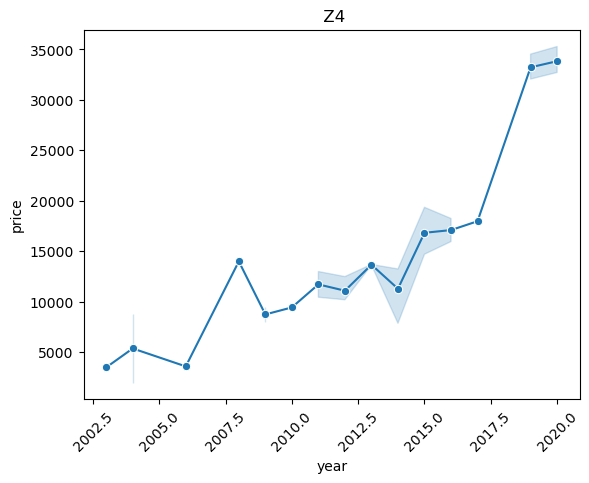

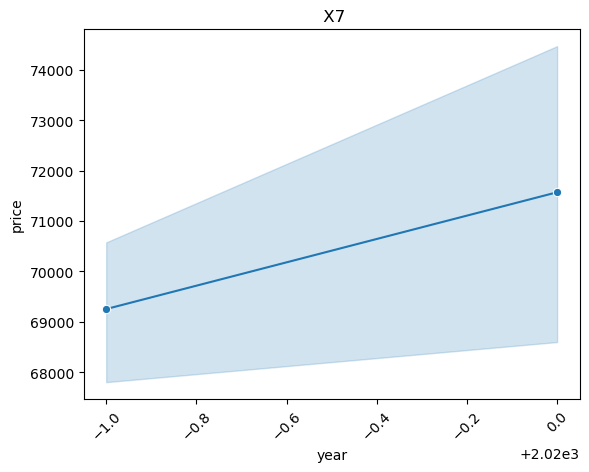

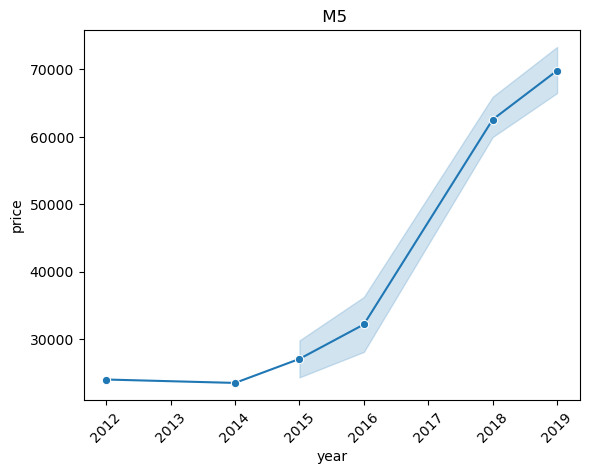

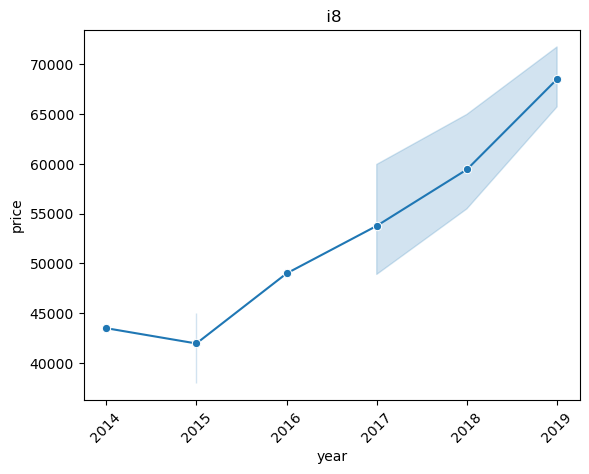

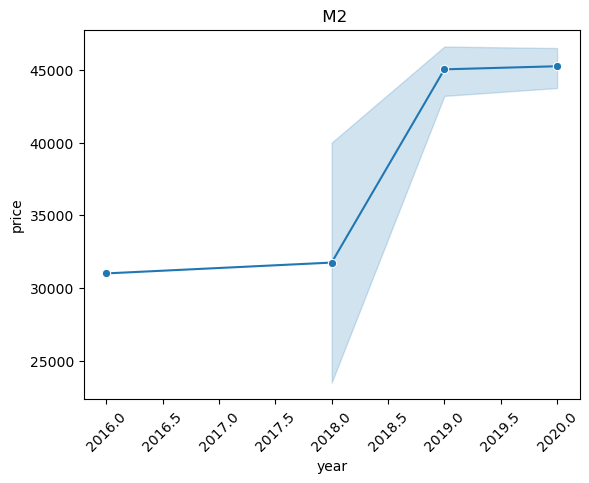

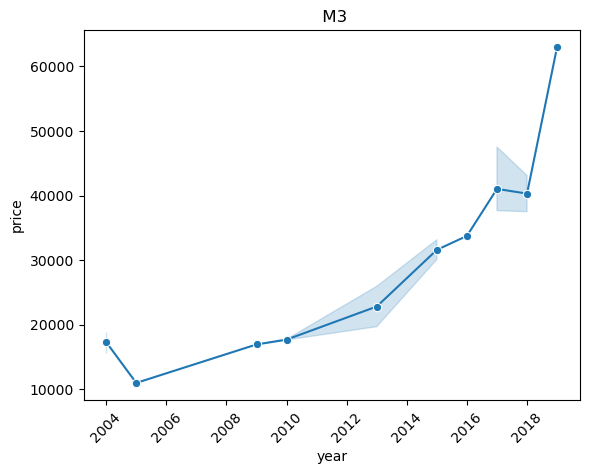

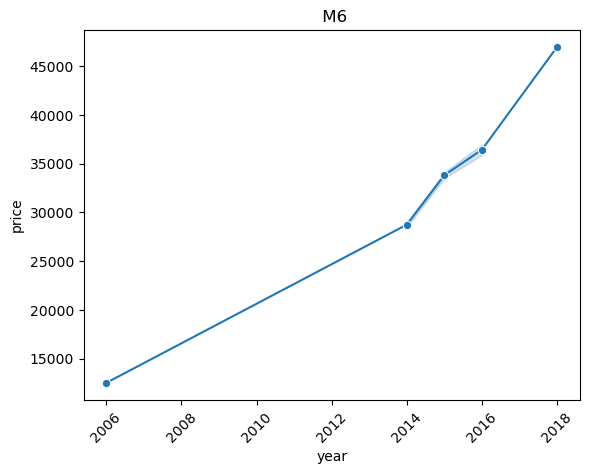

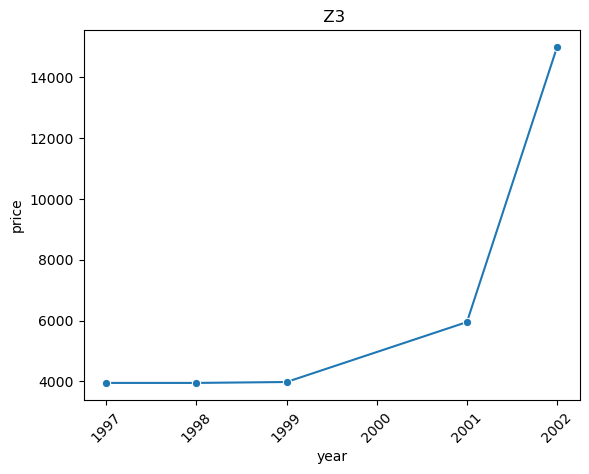

In [27]:
for m in df["model"].unique():
    temp = df[df["model"] == m]

    sns.lineplot(data=temp, x="year", y="price", marker="o")
    plt.title(m)
    plt.xticks(rotation=45)
    plt.show()


#avery year and avery car model price analysis

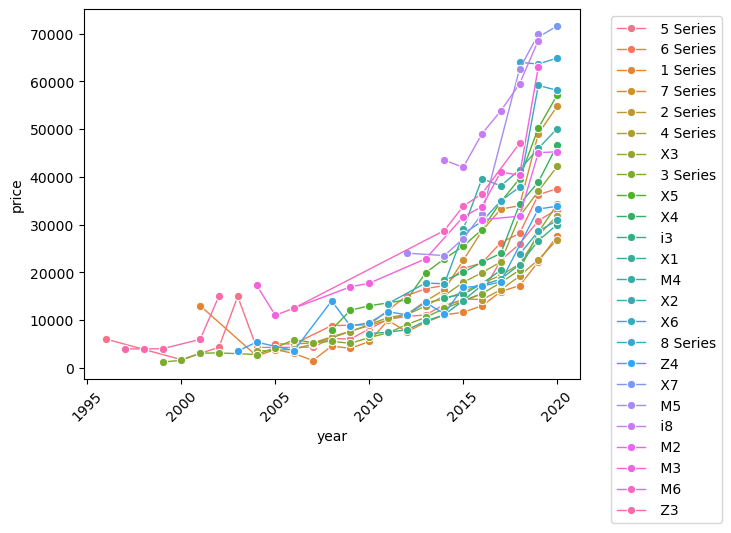

In [ ]:
sns.lineplot(data=df, x="year", y="price",marker="o",hue="model",errorbar=None,linewidth=1)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
#plt.tight_layout()
plt.show()


#same as above but in same pan

In [29]:
num_cols


['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']

<Axes: >

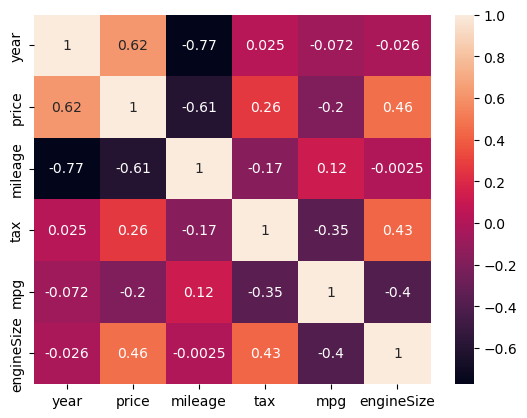

In [30]:
num_corr = df[['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']]

sns.heatmap(num_corr.corr(),annot=True)

# Bivariate analysis catigoral-numerical("target")

In [31]:
target = df["price"]
cat_cols

['model', 'transmission', 'fuelType']

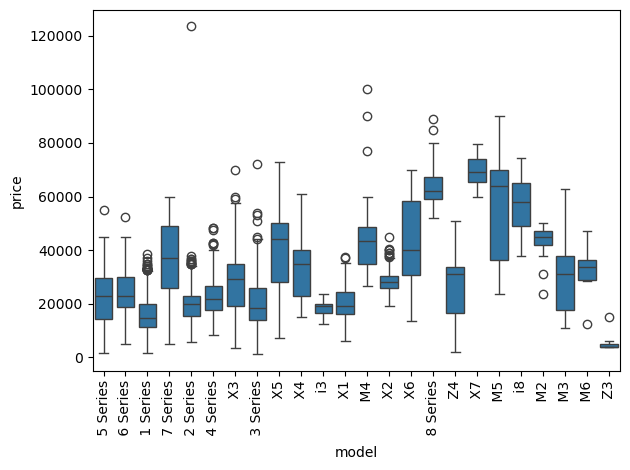

In [32]:
sns.boxplot(x = df["model"],y = df["price"])
plt.xticks(rotation=90)
plt.tight_layout()

same model but different price

<Axes: xlabel='transmission', ylabel='price'>

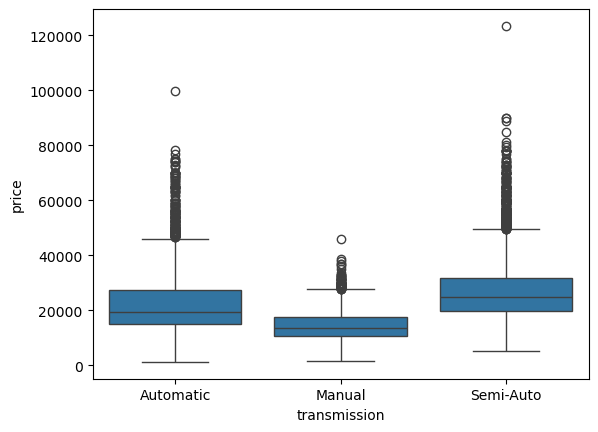

In [33]:
sns.boxplot(x = df["transmission"],y = df["price"])

semi-auto cars has higher price and manual transmission cars are cheap than other 2

<Axes: xlabel='fuelType', ylabel='price'>

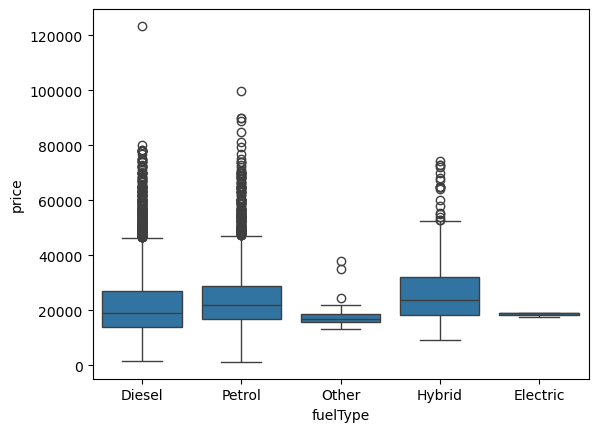

In [34]:
sns.boxplot(x = df["fuelType"],y = df["price"])

# Data Cleaning

In [35]:
new_data = df.copy()


In [36]:
new_data

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
...,...,...,...,...,...,...,...,...,...
10776,X3,2016,19000,Automatic,40818,Diesel,150,54.3,2.0
10777,5 Series,2016,14600,Automatic,42947,Diesel,125,60.1,2.0
10778,3 Series,2017,13100,Manual,25468,Petrol,200,42.8,2.0
10779,1 Series,2014,9930,Automatic,45000,Diesel,30,64.2,2.0


In [37]:
new_data.drop_duplicates(inplace=True)

In [38]:
new_data.shape

(10664, 9)

In [39]:
new_data["price"].value_counts()
new_data["mileage"].value_counts()
new_data["mpg"].value_counts()
new_data["engineSize"].value_counts()
new_data["year"].value_counts()

year
2019    3396
2016    1877
2017    1718
2015     921
2018     846
2020     722
2014     498
2013     355
2012     119
2011      51
2010      41
2009      29
2008      23
2007      16
2006      14
2004      12
2002       6
2005       6
1999       4
2001       3
2003       2
2000       2
1996       1
1997       1
1998       1
Name: count, dtype: int64

all columns has fair value and no empty row is present

In [40]:
new_data.dtypes

model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object

### Removing Outliers

In [41]:
Q1 = new_data['price'].quantile(0.25)
Q3 = new_data['price'].quantile(0.75)
IQR = Q3-Q1
lower = Q1 -1.5*IQR
upper = Q3 +1.5*IQR
new_data = new_data[(new_data['price']>=lower)&(new_data['price'] < upper)]

In [42]:
# creating new age columns for cars
new_data["age"]= 2025 - new_data["year"]
new_data.drop(columns=["year"],axis=1,inplace=True)

# split data

In [43]:
new_data

,model,price,transmission,mileage,fuelType,tax,mpg,engineSize,age
0,5 Series,11200,Automatic,67068,Diesel,125,57.6,2.0,11
1,6 Series,27000,Automatic,14827,Petrol,145,42.8,2.0,7
2,5 Series,16000,Automatic,62794,Diesel,160,51.4,3.0,9
3,1 Series,12750,Automatic,26676,Diesel,145,72.4,1.5,8
4,7 Series,14500,Automatic,39554,Diesel,160,50.4,3.0,11
...,...,...,...,...,...,...,...,...,...
10776,X3,19000,Automatic,40818,Diesel,150,54.3,2.0,9
10777,5 Series,14600,Automatic,42947,Diesel,125,60.1,2.0,9
10778,3 Series,13100,Manual,25468,Petrol,200,42.8,2.0,8
10779,1 Series,9930,Automatic,45000,Diesel,30,64.2,2.0,11


In [44]:
from sklearn.model_selection import train_test_split
x = new_data.drop(['price'],axis=1)
y = new_data["price"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)


# Data preprocessing

## Encoding

### One hot Encoding

In [45]:
new_data

,model,price,transmission,mileage,fuelType,tax,mpg,engineSize,age
0,5 Series,11200,Automatic,67068,Diesel,125,57.6,2.0,11
1,6 Series,27000,Automatic,14827,Petrol,145,42.8,2.0,7
2,5 Series,16000,Automatic,62794,Diesel,160,51.4,3.0,9
3,1 Series,12750,Automatic,26676,Diesel,145,72.4,1.5,8
4,7 Series,14500,Automatic,39554,Diesel,160,50.4,3.0,11
...,...,...,...,...,...,...,...,...,...
10776,X3,19000,Automatic,40818,Diesel,150,54.3,2.0,9
10777,5 Series,14600,Automatic,42947,Diesel,125,60.1,2.0,9
10778,3 Series,13100,Manual,25468,Petrol,200,42.8,2.0,8
10779,1 Series,9930,Automatic,45000,Diesel,30,64.2,2.0,11


In [46]:
from sklearn.preprocessing import OneHotEncoder
one_hot = OneHotEncoder(drop="first",sparse_output=False,)
x_train_oh = one_hot.fit_transform(x_train[["transmission","fuelType","model"]])
x_test_oh = one_hot.transform(x_test[["transmission","fuelType","model"]])


In [47]:
print(one_hot.get_feature_names_out())
x_train_index = x_train.index


['transmission_Manual' 'transmission_Semi-Auto' 'fuelType_Electric'
 'fuelType_Hybrid' 'fuelType_Other' 'fuelType_Petrol' 'model_ 2 Series'
 'model_ 3 Series' 'model_ 4 Series' 'model_ 5 Series' 'model_ 6 Series'
 'model_ 7 Series' 'model_ M2' 'model_ M3' 'model_ M4' 'model_ M5'
 'model_ M6' 'model_ X1' 'model_ X2' 'model_ X3' 'model_ X4' 'model_ X5'
 'model_ X6' 'model_ Z3' 'model_ Z4' 'model_ i3' 'model_ i8']


In [48]:
x_train_oh = pd.DataFrame(x_train_oh,columns=one_hot.get_feature_names_out(),index=x_train.index)
x_test_oh = pd.DataFrame(x_test_oh,columns=one_hot.get_feature_names_out(),index=x_test.index)

In [49]:
x_train_oh

,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,model_ 2 Series,model_ 3 Series,model_ 4 Series,model_ 5 Series,...,model_ X1,model_ X2,model_ X3,model_ X4,model_ X5,model_ X6,model_ Z3,model_ Z4,model_ i3,model_ i8
2339,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5447,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2732,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9580,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2394,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6178,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5583,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5797,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
902,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
new_data

,model,price,transmission,mileage,fuelType,tax,mpg,engineSize,age
0,5 Series,11200,Automatic,67068,Diesel,125,57.6,2.0,11
1,6 Series,27000,Automatic,14827,Petrol,145,42.8,2.0,7
2,5 Series,16000,Automatic,62794,Diesel,160,51.4,3.0,9
3,1 Series,12750,Automatic,26676,Diesel,145,72.4,1.5,8
4,7 Series,14500,Automatic,39554,Diesel,160,50.4,3.0,11
...,...,...,...,...,...,...,...,...,...
10776,X3,19000,Automatic,40818,Diesel,150,54.3,2.0,9
10777,5 Series,14600,Automatic,42947,Diesel,125,60.1,2.0,9
10778,3 Series,13100,Manual,25468,Petrol,200,42.8,2.0,8
10779,1 Series,9930,Automatic,45000,Diesel,30,64.2,2.0,11


# Feature Engineering

### StandardScaler

In [58]:
new_data

,model,price,transmission,mileage,fuelType,tax,mpg,engineSize,age
0,5 Series,11200,Automatic,67068,Diesel,125,57.6,2.0,11
1,6 Series,27000,Automatic,14827,Petrol,145,42.8,2.0,7
2,5 Series,16000,Automatic,62794,Diesel,160,51.4,3.0,9
3,1 Series,12750,Automatic,26676,Diesel,145,72.4,1.5,8
4,7 Series,14500,Automatic,39554,Diesel,160,50.4,3.0,11
...,...,...,...,...,...,...,...,...,...
10776,X3,19000,Automatic,40818,Diesel,150,54.3,2.0,9
10777,5 Series,14600,Automatic,42947,Diesel,125,60.1,2.0,9
10778,3 Series,13100,Manual,25468,Petrol,200,42.8,2.0,8
10779,1 Series,9930,Automatic,45000,Diesel,30,64.2,2.0,11


In [59]:
cols = ["age","mileage","mpg","engineSize","tax"]
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_st = scaler.fit_transform(x_train[cols])
x_test_st = scaler.transform(x_test[cols])
x_train_st

array([[-0.85769862, -0.86176914,  0.08688157, -0.25217328,  0.21035195],
       [ 1.24552422,  0.96728986, -0.15437078, -0.25217328,  0.44573454],
       [-0.43705406, -0.54559278, -0.12344099, -1.20827397,  0.21035195],
       ...,
       [-0.85769862, -0.62321525, -0.48841249, -1.20827397,  0.28881281],
       [-0.85769862, -0.57223574,  0.170392  , -0.25217328,  0.21035195],
       [-0.85769862, -0.99208105,  0.26008838, -0.25217328,  0.21035195]])

In [60]:
x_train_st = pd.DataFrame(x_train_st,columns=cols,index=x_train.index)
x_test_st = pd.DataFrame(x_test_st,columns=cols,index=x_test.index)

In [61]:
x_train = pd.concat(
    [x_train_st, x_train_oh],
    axis=1
)
x_test = pd.concat(
    [x_test_st, x_test_oh],
    axis=1
)

In [62]:
x_test

,age,mileage,mpg,engineSize,tax,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,...,model_ X1,model_ X2,model_ X3,model_ X4,model_ X5,model_ X6,model_ Z3,model_ Z4,model_ i3,model_ i8
4184,-0.857699,-0.838983,0.411644,-1.208274,0.288813,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6580,-0.857699,-0.707280,-0.092511,-0.252173,0.210352,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4432,-0.016409,0.350088,-0.540993,1.660028,0.210352,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
749,-0.016409,-0.361001,-0.123441,1.660028,0.210352,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3358,-0.857699,-0.804825,0.260088,-0.252173,0.210352,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5385,-0.857699,-1.057336,0.411644,-1.208274,0.210352,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5694,-0.857699,-0.829400,-0.265718,-0.252173,0.288813,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
588,1.245524,-0.223054,0.213694,-0.252173,-1.594248,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1714,-0.857699,-1.052843,-0.339950,-0.252173,0.210352,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Feature Extraction

In [71]:
x_train.columns

Index(['age', 'mileage', 'mpg', 'engineSize', 'tax', 'transmission_Manual',
       'transmission_Semi-Auto', 'fuelType_Electric', 'fuelType_Hybrid',
       'fuelType_Other', 'fuelType_Petrol', 'model_ 2 Series',
       'model_ 3 Series', 'model_ 4 Series', 'model_ 5 Series',
       'model_ 6 Series', 'model_ 7 Series', 'model_ M2', 'model_ M3',
       'model_ M4', 'model_ M5', 'model_ M6', 'model_ X1', 'model_ X2',
       'model_ X3', 'model_ X4', 'model_ X5', 'model_ X6', 'model_ Z3',
       'model_ Z4', 'model_ i3', 'model_ i8', 'price_bin'],
      dtype='object')

In [67]:
num_features = ['age', 'mileage', 'tax', 'mpg', 'engineSize']
cat_features = ['transmission_Manual',
       'transmission_Semi-Auto', 'fuelType_Electric', 'fuelType_Hybrid',
       'fuelType_Other', 'fuelType_Petrol', 'model_ 2 Series',
       'model_ 3 Series', 'model_ 4 Series', 'model_ 5 Series',
       'model_ 6 Series', 'model_ 7 Series', 'model_ M3',
       'model_ M4', 'model_ M5', 'model_ M6', 'model_ X1', 'model_ X2',
       'model_ X3', 'model_ X4', 'model_ X5', 'model_ X6', 'model_ Z3',
       'model_ Z4', 'model_ i3', 'model_ i8']

#### for numerical columns

In [68]:
from scipy.stats import pearsonr
correlations = {
    feature:pearsonr(x_train[feature],
    y_train)[0]
    for feature in num_features
}
correlations_df = pd.DataFrame(list(correlations.items()),columns=["feature","person_correlation"])
correlations_df.sort_values(by ="person_correlation",ascending=False)

,feature,person_correlation
4,engineSize,0.333856
2,tax,0.306532
3,mpg,-0.168837
1,mileage,-0.676868
0,age,-0.695182


#### use for catigory columns

###### check columns desision

In [69]:
print(x_train.columns)
print(x_test.columns)

Index(['age', 'mileage', 'mpg', 'engineSize', 'tax', 'transmission_Manual',
       'transmission_Semi-Auto', 'fuelType_Electric', 'fuelType_Hybrid',
       'fuelType_Other', 'fuelType_Petrol', 'model_ 2 Series',
       'model_ 3 Series', 'model_ 4 Series', 'model_ 5 Series',
       'model_ 6 Series', 'model_ 7 Series', 'model_ M2', 'model_ M3',
       'model_ M4', 'model_ M5', 'model_ M6', 'model_ X1', 'model_ X2',
       'model_ X3', 'model_ X4', 'model_ X5', 'model_ X6', 'model_ Z3',
       'model_ Z4', 'model_ i3', 'model_ i8', 'price_bin'],
      dtype='object')
Index(['age', 'mileage', 'mpg', 'engineSize', 'tax', 'transmission_Manual',
       'transmission_Semi-Auto', 'fuelType_Electric', 'fuelType_Hybrid',
       'fuelType_Other', 'fuelType_Petrol', 'model_ 2 Series',
       'model_ 3 Series', 'model_ 4 Series', 'model_ 5 Series',
       'model_ 6 Series', 'model_ 7 Series', 'model_ M2', 'model_ M3',
       'model_ M4', 'model_ M5', 'model_ M6', 'model_ X1', 'model_ X2',
       '

In [70]:
from scipy.stats import chi2_contingency
import pandas as pd

# make price bins first (if not already done)
x_train["price_bin"] = pd.qcut(y_train, q=4, labels=False)

# choose your categorical / dummy columns
cat_cols = [
    col for col in x_train.columns
    if x_train[col].dropna().isin([0,1]).all()
]

results = []

for col in cat_features:
    table = pd.crosstab(x_train[col], x_train["price_bin"])
    stat, p, dof, exp = chi2_contingency(table)

    # Append col name + p-value
    results.append((col, p))

# Create dataframe
results_df = pd.DataFrame(results, columns=["feature","p_value"])

# Add Decision column
alpha = 0.05
results_df["Decision"] = results_df["p_value"].apply(
    lambda p: "Accept H0 (Significant)" if p < alpha else "Fail to Reject H0 (Not Significant)"
)

# Sort by p-value
results_df = results_df.sort_values("p_value")

results_df


,feature,p_value,Decision
0,transmission_Manual,0.000000e+00,Accept H0 (Significant)
1,transmission_Semi-Auto,8.866553e-306,Accept H0 (Significant)
20,model_ X5,5.002687e-51,Accept H0 (Significant)
17,model_ X2,5.795473e-51,Accept H0 (Significant)
6,model_ 2 Series,3.767237e-46,Accept H0 (Significant)
13,model_ M4,1.100465e-38,Accept H0 (Significant)
5,fuelType_Petrol,1.133338e-38,Accept H0 (Significant)
18,model_ X3,1.325134e-33,Accept H0 (Significant)
8,model_ 4 Series,2.181047e-31,Accept H0 (Significant)
16,model_ X1,4.326600e-21,Accept H0 (Significant)


In [59]:
#remove not significant columns
x_train.drop("fuelType_Electric",axis=1,inplace=True)
x_train.drop("model_ M6",axis=1,inplace=True)
x_train.drop("model_ M5",axis=1,inplace=True)



In [60]:
x_test.drop("fuelType_Electric",axis=1,inplace=True)
x_test.drop("model_ M6",axis=1,inplace=True)
x_test.drop("model_ M5",axis=1,inplace=True)

#After all this all columns are selected for model training

In [61]:
y_train

,price
2339,25745
5447,11000
2732,16275
9580,13499
2394,20498
...,...
6178,28999
5583,11295
5797,22890
902,26000


In [62]:
x_train.drop("price_bin",axis=1,inplace=True)

# Model Training

### Log transformation

In [63]:
y_train = np.log1p(y_train)
y_train

,price
2339,10.156035
5447,9.305741
2732,9.697447
9580,9.510445
2394,9.928131
...,...
6178,10.275051
5583,9.332204
5797,10.038499
902,10.165890


In [64]:
#original price col of x_train
y_train_original = np.expm1(y_train)
y_train_original

,price
2339,25745.0
5447,11000.0
2732,16275.0
9580,13499.0
2394,20498.0
...,...
6178,28999.0
5583,11295.0
5797,22890.0
902,26000.0


### Linear regression model training

In [65]:
linear_model = LinearRegression()
linear_model.fit(x_train,y_train)

LinearRegression()

In [66]:
y_pred_log_linear = linear_model.predict(x_test)
y_pred_linear = np.expm1(y_pred_log_linear)


r2 = r2_score(y_test,y_pred_linear)
mae = mean_absolute_error(y_test,y_pred_linear)
mse = mean_squared_error(y_test,y_pred_linear)
rmse = np.sqrt(mean_squared_error(y_test,y_pred_linear))
print("r2_score:",r2)
print("mae: ",mae)
print("mse: ", mse)
print("rmse: ",rmse)
print(rmse/(y_train_original.mean()))



r2_score: 0.9071395143063943
mae:  1807.045158632413
mse:  6679681.392157588
rmse:  2584.5079593914174
0.12262772306955885


In [67]:
y_test

,price
4184,18480
6580,31116
4432,19798
749,20498
3358,26350
...,...
5385,23450
5694,27490
588,11998
1714,31175


rmse is 12 % of avg price is good and also r2 score is good

In [68]:
y_train

,price
2339,10.156035
5447,9.305741
2732,9.697447
9580,9.510445
2394,9.928131
...,...
6178,10.275051
5583,9.332204
5797,10.038499
902,10.165890


### knn model training

In [69]:
model_knn = KNeighborsRegressor(n_neighbors=5)
model_knn.fit(x_train,y_train)


KNeighborsRegressor()

In [70]:
#make prediction
y_pred_log_knn = model_knn.predict(x_test)
#convert log prediction back to original price
y_pred_knn = np.expm1(y_pred_log_knn)


r2 = r2_score(y_test,y_pred_knn)
mae = mean_absolute_error(y_test,y_pred_knn)
mse = mean_squared_error(y_test,y_pred_knn)
rmse = np.sqrt(mean_squared_error(y_test,y_pred_knn))
print("r2_score:",r2)
print("mae: ",mae)
print("mse: ", mse)
print("rmse: ",rmse)
print(rmse/(y_train_original.mean()))



r2_score: 0.9210480287441924
mae:  1563.8663534983111
mse:  5679208.000393788
rmse:  2383.108893943747
0.11307189688823789


y_train

### decisiontreeregresion model training

In [71]:
model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(x_train,y_train)

DecisionTreeRegressor(random_state=42)

In [72]:
# make prediction
y_pred_log_dt = model_dt.predict(x_test)
# convert log prediction back to original price
y_pred_dt = np.expm1(y_pred_log_dt)


r2 = r2_score(y_test,y_pred_dt)
mae = mean_absolute_error(y_test,y_pred_dt)
mse = mean_squared_error(y_test,y_pred_dt)
rmse = np.sqrt(mean_squared_error(y_test,y_pred_dt))
print("r2_score:",r2)
print("mae: ",mae)
print("mse: ", mse)
print("rmse: ",rmse)
print(rmse/(y_train_original.mean()))



r2_score: 0.8999837815611569
mae:  1815.5329479314892
mse:  5679208.000393788
rmse:  2682.239868918429
0.12726483068340408


### RandomForestRegressor model training

In [73]:
model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [74]:
#make prediction
y_pred_log_rf = model_rf.predict(x_test)
#convert back log prediction back to original price
y_pred_rf = np.expm1(y_pred_log_rf)


r2 = r2_score(y_test,y_pred_rf)
mae = mean_absolute_error(y_test,y_pred_rf)
mse = mean_squared_error(y_test,y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test,y_pred_rf))
print("r2_score:",r2)
print("mae: ",mae)
print("mse: ", mse)
print("rmse: ",rmse)
print(rmse/(y_train_original.mean()))


r2_score: 0.9394792648338887
mae:  1410.4659502308468
mse:  4353404.201035834
rmse:  2086.4812965938213
0.0989977414071379


# Model tunning

## cross valation

In [75]:
from sklearn.model_selection import cross_val_score
scores_rf = cross_val_score(model_rf,x_train,y_train,cv=5,scoring="r2")
scores_dt = cross_val_score(model_dt,x_train,y_train,cv=5,scoring="r2")
scores_knn = cross_val_score(model_knn,x_train,y_train,cv=5,scoring="r2")
scores_linear = cross_val_score(linear_model,x_train,y_train,cv=5,scoring="r2")

print(f"model_rf :{scores_rf} mean = {scores_rf.mean()}\nmodel_dt :{scores_dt}  mean = {scores_dt.mean()}\nmodel_knn : {scores_knn}  mean = {scores_knn.mean()}\nmodel_linear : {scores_linear}  mean = {scores_linear.mean()}")

model_rf :[0.93813047 0.93846392 0.94611034 0.93830723 0.93582075] mean = 0.9393665434363168
model_dt :[0.88784412 0.90256735 0.8995634  0.89921248 0.89911518]  mean = 0.8976605063454033
model_knn : [0.93217733 0.93419426 0.93665505 0.92343214 0.92284877]  mean = 0.9298615128358598
model_linear : [0.91333514 0.92024775 0.92868832 0.91282702 0.91178012]  mean = 0.917375671788451


#model_rf has highest accuracy scores

## hyperperimeter tunning

In [76]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

random_search = RandomizedSearchCV(
    estimator=model_rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(x_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, None],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=2)

In [77]:
print(random_search.best_params_)
best_model = random_search.best_estimator_
#make prediction
y_pred_log = best_model.predict(x_test)
# convert back log prediction back to original price
y_pred = np.expm1(y_pred_log)


{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}


In [78]:
y_pred

array([18171.18012004, 33768.38289174, 20422.58326078, ...,
       12400.37839028, 27312.89422858,  9844.51920312])

In [79]:
print(x_test.shape)
print(x_train.shape)
print(y_train.shape)
print(y_test.shape)

(2547, 29)
(7639, 29)
(7639,)
(2547,)


In [80]:
y_train

,price
2339,10.156035
5447,9.305741
2732,9.697447
9580,9.510445
2394,9.928131
...,...
6178,10.275051
5583,9.332204
5797,10.038499
902,10.165890


In [81]:
print("R2:", r2_score(y_test, y_pred))
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))

print("mae:",mae)
print("mse:",mse)
print("rmse/y_train['price']",rmse/(y_train_original.mean()))

R2: 0.9404974134860504
mae: 1390.1422002402935
mse: 4280166.283362918
rmse/y_train['price'] 0.09816148305653451


# checking train test accuracy

In [82]:
print(y_train_original.mean())

21076.049482916613


In [83]:
train_pred_log = best_model.predict(x_train)

train_pred = np.expm1(train_pred_log)

test_pred_log = best_model.predict(x_test)

test_pred = np.expm1(test_pred_log)


In [85]:
train_acc = r2_score(y_train_original,train_pred)
test_acc = r2_score(y_test,test_pred)
print("train accuracy ",train_acc)
print("test accuracy ",test_acc)

train accuracy  0.9822589186732756
test accuracy  0.9404974134860504


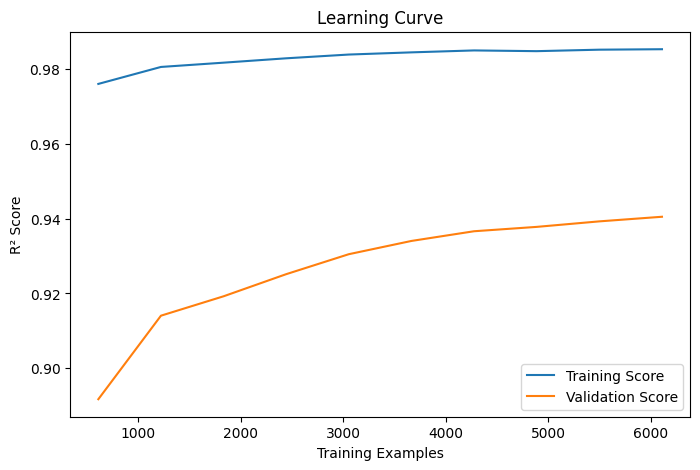

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    x_train,
    y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Mean scores
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# Plot
plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")

plt.xlabel("Training Examples")
plt.ylabel("R² Score")
plt.title("Learning Curve")
plt.legend()

plt.show()


Curve Actually Shows Something GOOD

Notice this important behavior:

Validation score keeps increasing steadily

This is excellent.

It means:

model benefits from more data
generalization improves
not collapsing



### Residuals plot

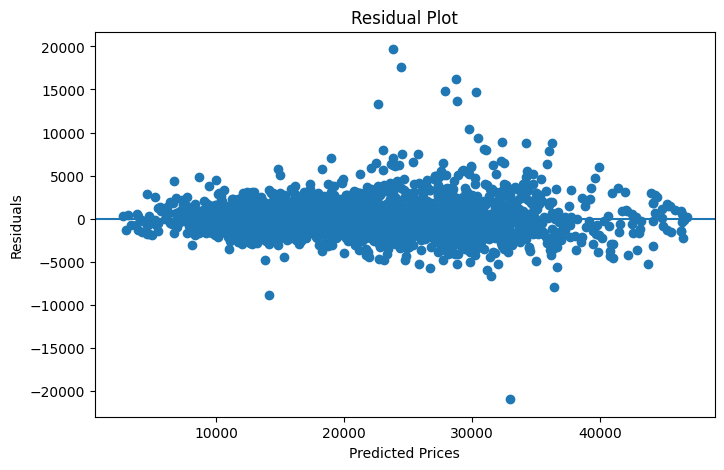

In [90]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(test_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

### Compare metrics of different models

In [94]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)


results = []

models = {
    "Linear Regression": linear_model,
    "KNN": model_knn,
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
    "random_search": best_model
}

for name, model in models.items():

    # Train
    model.fit(x_train, y_train)

    # Predict
    train_pred_log = model.predict(x_train)
    test_pred_log = model.predict(x_test)

    # Convert back from log scale
    train_pred = np.expm1(train_pred_log)
    test_pred = np.expm1(test_pred_log)

    y_train_original = y_train_original
    y_test_original = y_test

    # Metrics
    train_r2 = r2_score(y_train_original, train_pred)

    test_r2 = r2_score(y_test_original, test_pred)

    mae = mean_absolute_error(
        y_test_original,
        test_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_original,
            test_pred
        )
    )
    cv_scores = cross_val_score(
    model,
    x_train,
    y_train,
    cv=5,
    scoring="r2"
  )

    cv_mean = cv_scores.mean()

    gap = train_r2 - test_r2

    # Save results
    results.append({
        "Model": name,
        "Train R2": round(train_r2, 3),
        "Test R2": round(test_r2, 3),
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "RMSE/y_train_mean": round(rmse / y_train_original.mean(), 2),
        "CV Mean": round(cv_mean, 3),
        "Overfit Gap": round(gap, 3),

    })

# ==============================
# Create Table
# ==============================

results_df = pd.DataFrame(results)

# Sort by best Test R2
results_df = results_df.sort_values(
    by="Test R2",
    ascending=False
)

print(results_df)

               Model  Train R2  Test R2      MAE     RMSE  RMSE/y_train_mean  \
4      random_search     0.982    0.940  1390.14  2068.86               0.10   
3      Random Forest     0.990    0.939  1410.47  2086.48               0.10   
1                KNN     0.951    0.921  1563.87  2383.11               0.11   
0  Linear Regression     0.898    0.907  1807.05  2584.51               0.12   
2      Decision Tree     1.000    0.900  1815.53  2682.24               0.13   

   CV Mean  Overfit Gap  
4    0.940        0.042  
3    0.939        0.051  
1    0.930        0.030  
0    0.917       -0.009  
2    0.898        0.100  


In [101]:


# Create the results DataFrame
results_df = pd.DataFrame(results)

# Rename columns for clarity
results_df = results_df.rename(columns={
    "Train R2": "Train R",
    "Test R2": "Test R",
    "CV Mean": "CV R",
    "Overfit Gap": "Gap",
    "RMSE/y_test_mean": "RMSE %"
})

# Sort by performance and reset index for Ranking
results_df = results_df.sort_values(by="Test R", ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1
results_df.index.name = "Rank"

# Round numeric values
results_df = results_df.round({
    "Train R": 3,
    "Test R": 3,
    "CV R": 3,
    "Gap": 3,
    "MAE": 3,
    "RMSE": 3,
    "RMSE %": 2
})

# Force the table to stay horizontal with a scrollbar using CSS
display(results_df.style.set_table_attributes('style="display: inline-block; white-space: nowrap; overflow-x: auto; max-width: 100%;"'))

,Model,Train R,Test R,MAE,RMSE,RMSE/y_train_mean,CV R,Gap
Rank,,,,,,,,
1,random_search,0.982000,0.940000,1390.140000,2068.860000,0.100000,0.940000,0.042000
2,Random Forest,0.990000,0.939000,1410.470000,2086.480000,0.100000,0.939000,0.051000
3,KNN,0.951000,0.921000,1563.870000,2383.110000,0.110000,0.930000,0.030000
4,Linear Regression,0.898000,0.907000,1807.050000,2584.510000,0.120000,0.917000,-0.009000
5,Decision Tree,1.000000,0.900000,1815.530000,2682.240000,0.130000,0.898000,0.100000


### Feature Importance for Random Forest

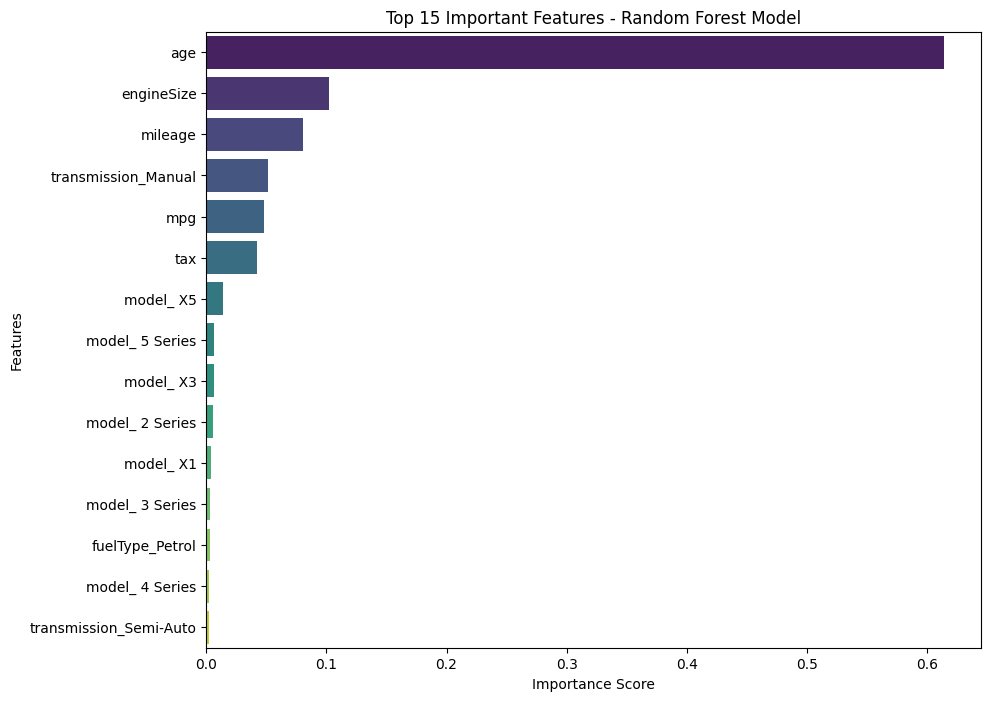

In [102]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Get feature importances from the Random Forest model
importances = model_rf.feature_importances_
feature_names = x_train.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 15 features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Important Features - Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Saving Model

In [103]:
import pickle
artifact = {
    "model": best_model,
    "columns": x_train.columns,
    "encoder":one_hot,
    "scaler":scaler
}

with open("bmw_model.pkl", "wb") as f:
    pickle.dump(artifact, f)